# Gen AI Statement

In [1]:
import os
import numpy as np
from PIL import Image

# Folder containing your images
folder = "cropped_faces"

# Collect flattened images here
rows = []

for fname in os.listdir(folder):
    if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
        path = os.path.join(folder, fname)
        img = Image.open(path).convert("L")   # "L" makes grayscale, use "RGB" if you want 3 channels
        img = img.resize((127, 127))          # ensures consistent size
        flat = np.array(img).flatten()        # shape (16129,)
        rows.append(flat)

# Final matrix: each row is one flattened image
A = np.vstack(rows)
print("Shape of A:", A.shape)  # (num_images, 16129)


Shape of A: (3279, 16129)


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def show_face(row_vector, size=(127, 127), rgb=False):
    """
    Reconstitute a flattened row vector into an image and display it.
    
    Parameters
    ----------
    row_vector : numpy array (1D)
        Flattened image (length 16129 for grayscale, or 48387 for RGB).
    size : tuple
        (width, height) of the original image.
    rgb : bool
        True if image was stored with 3 channels (RGB), False for grayscale.
    """
    if rgb:
        img = row_vector.reshape(size[1], size[0], 3)  # (127,127,3)
        plt.imshow(img.astype(np.uint8))
    else:
        img = row_vector.reshape(size)  # (127,127)
        plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()


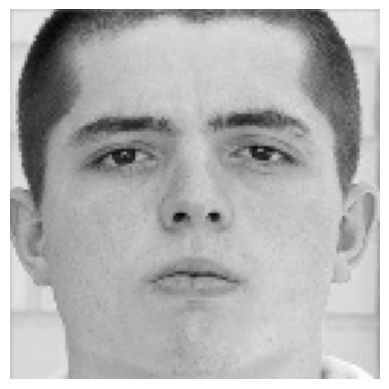

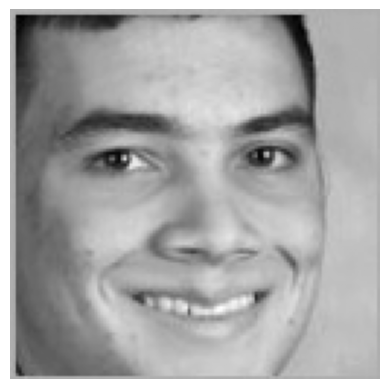

In [3]:
show_face(A[0])
show_face(A[3278])

Number of singular values: 3279


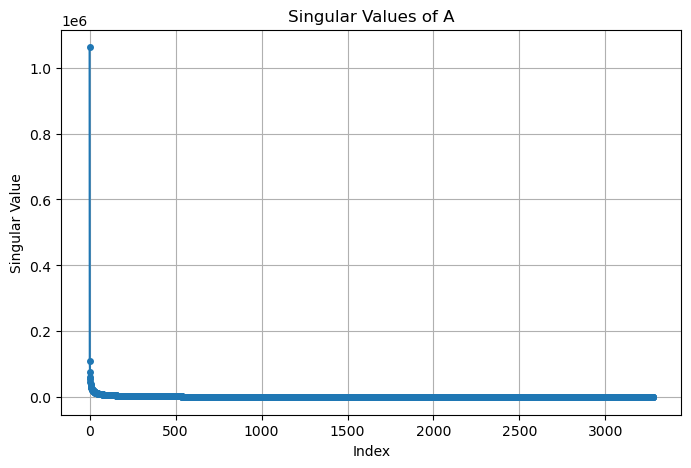

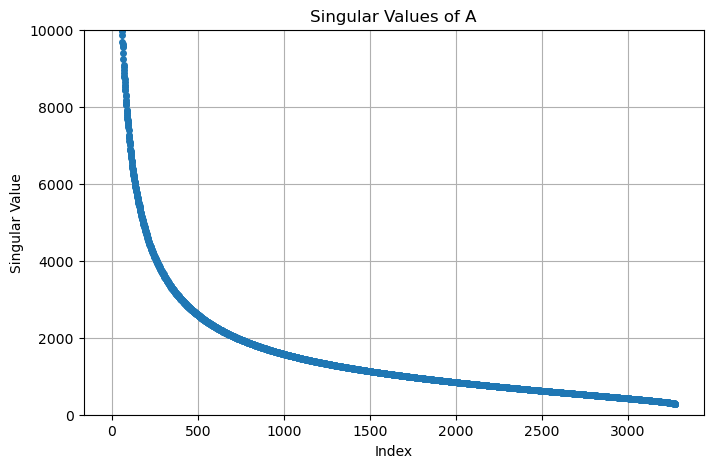

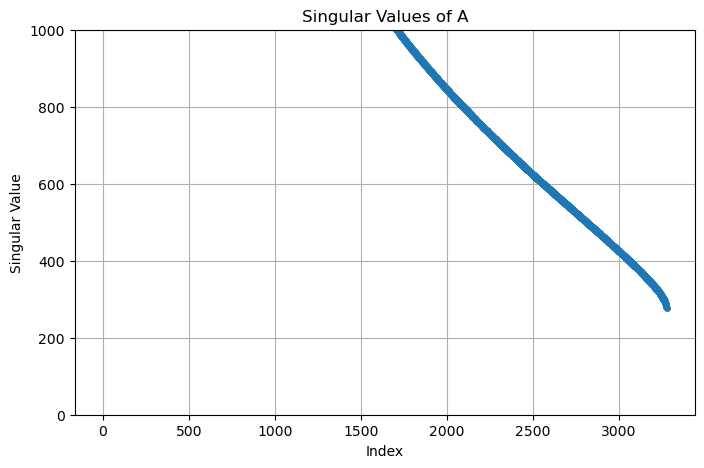

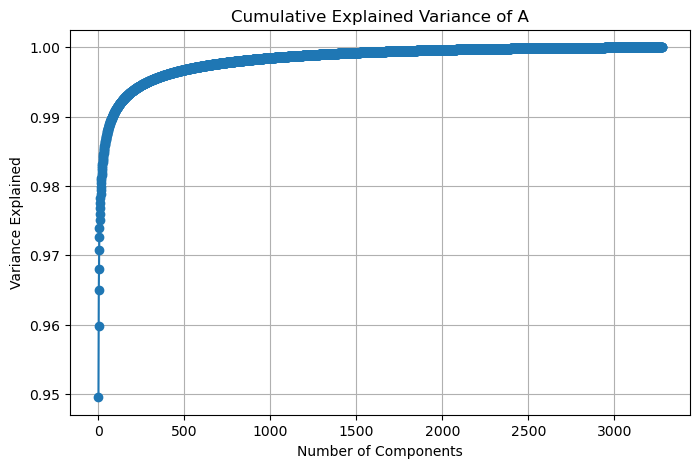

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Compute SVD of A
U, s, Vt = np.linalg.svd(A, full_matrices=False)

# s contains the singular values
print("Number of singular values:", len(s))

# Plot singular values
plt.figure(figsize=(8,5))
plt.plot(s, 'o-', markersize=4)
plt.title("Singular Values of A")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

# Plot singular values
plt.figure(figsize=(8,5))
plt.plot(s, 'o-', markersize=4)
plt.title("Singular Values of A")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.ylim(0, 10000)   # y-axis from 0 to 1000
plt.grid(True)
plt.show()

# Plot singular values
plt.figure(figsize=(8,5))
plt.plot(s, 'o-', markersize=4)
plt.title("Singular Values of A")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.ylim(0, 1000)   # y-axis from 0 to 1000
plt.grid(True)
plt.show()

# Optional: cumulative explained variance
explained_variance = np.cumsum(s**2) / np.sum(s**2)
plt.figure(figsize=(8,5))
plt.plot(explained_variance, 'o-')
plt.title("Cumulative Explained Variance of A")
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained")
plt.grid(True)
plt.show()

# Singular Values explained

The steep drop off in the singular values of A show that there are around 500 that are more important to the value than the rest of the features. But each feature has a singular value of above 0, and therefore the rank is the number of pictures or 3279



In [5]:
tol = .00001
rank = np.sum(s > tol)
print("Rank of A:", rank)


Rank of A: 3279


# The Rank of A is 3279

We believe that there is noise beyond a k value of around 800, because it in the elbow of the singular values graph. The values before are the most important and each values impact afterwards is not as necessary to recreate the faces.

In [6]:
def low_rank_approx(U, s, Vt, k):
    """
    Return the rank-k approximation A_k = U_k Σ_k V_k^T.

    Parameters
    ----------
    U  : (m, r) left singular vectors  (from np.linalg.svd(A, full_matrices=False))
    s  : (r,)   singular values
    Vt : (r, n) right singular vectors transposed
    k  : int    number of components to keep

    Returns
    -------
    A_k : (m, n) low-rank approximation of A
    """
    k = int(k)
    Uk  = U[:, :k]        # (m, k)
    sk  = s[:k]           # (k,)
    Vtk = Vt[:k, :]       # (k, n)
    return (Uk * sk) @ Vtk  # (m, k) * (k,) -> (m, k); then @ (k, n) -> (m, n)


In [24]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)
A5   = low_rank_approx(U, s, Vt, k=5)
A200  = low_rank_approx(U, s, Vt, k=200)
A800  = low_rank_approx(U, s, Vt, k=800)
A1300  = low_rank_approx(U, s, Vt, k=1300)
A1700 = low_rank_approx(U, s, Vt, k=1700)

print(A5.shape, A.shape)   # should match A's shape


(3279, 16129) (3279, 16129)


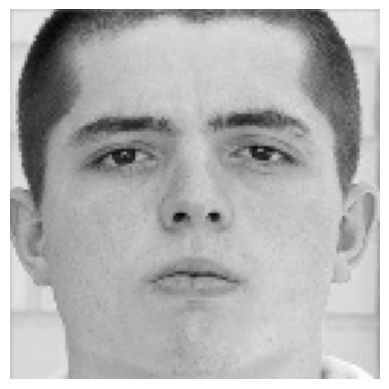

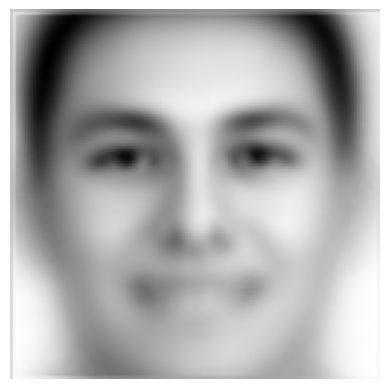

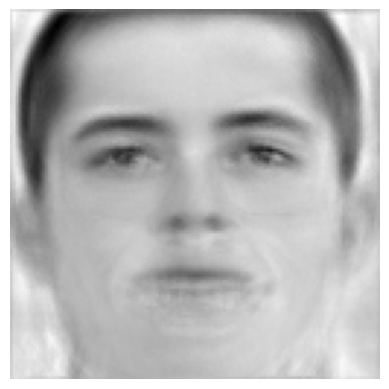

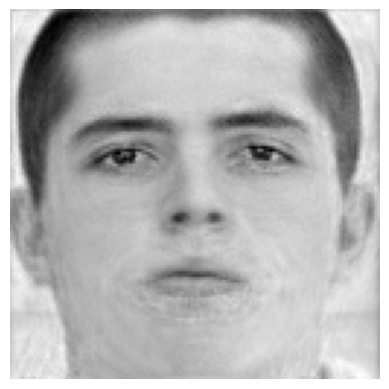

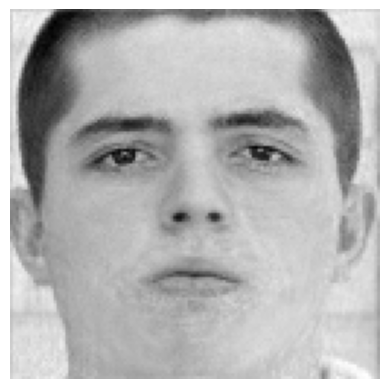

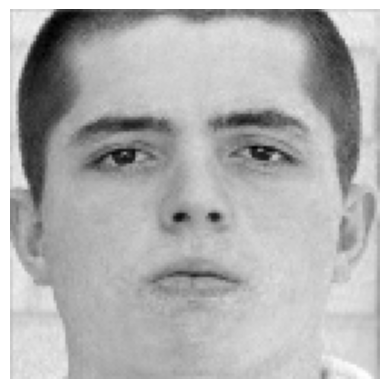

In [25]:
show_face(A[0])
show_face(A5[0])
show_face(A200[0])
show_face(A800[0])
show_face(A1300[0])
show_face(A1700[0])

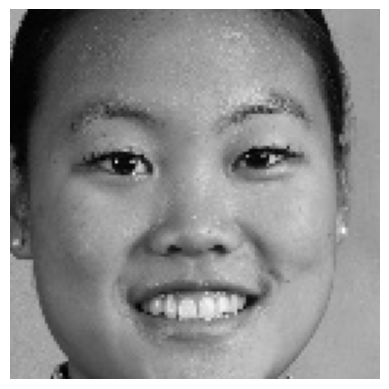

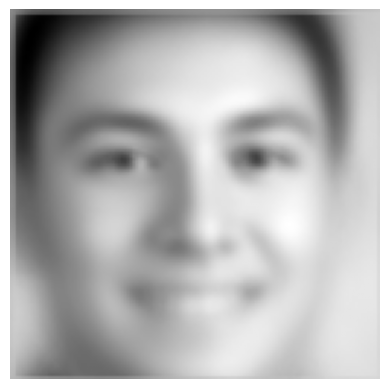

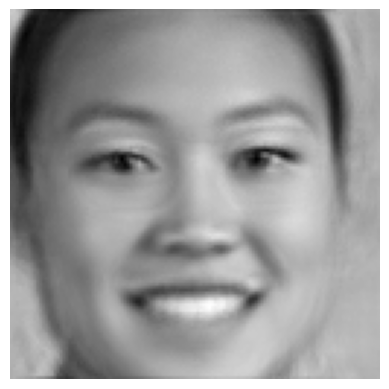

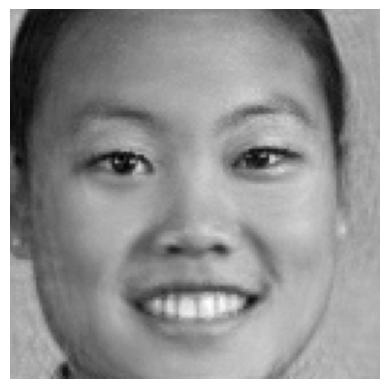

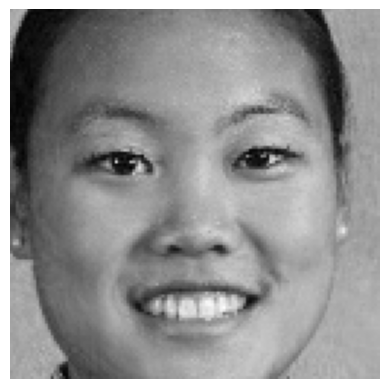

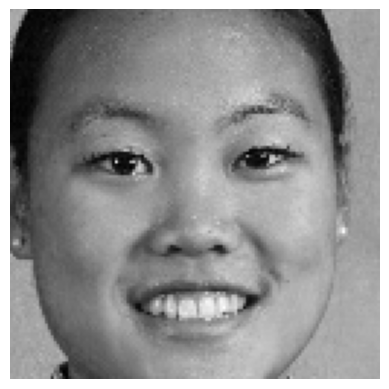

In [26]:
show_face(A[10])
show_face(A5[10])
show_face(A200[10])
show_face(A800[10])
show_face(A1300[10])
show_face(A1700[10])

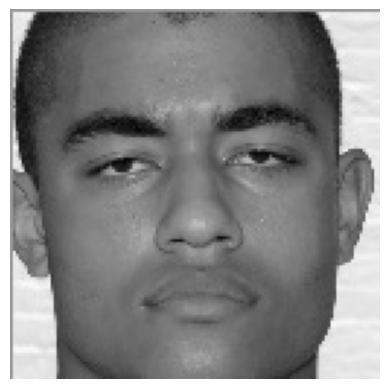

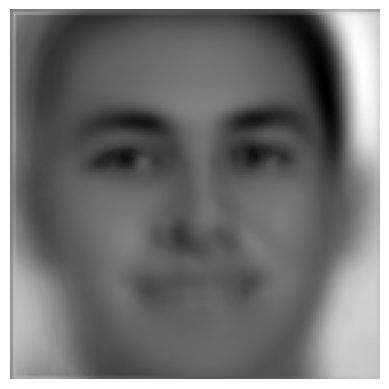

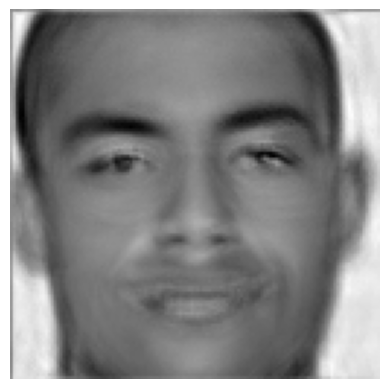

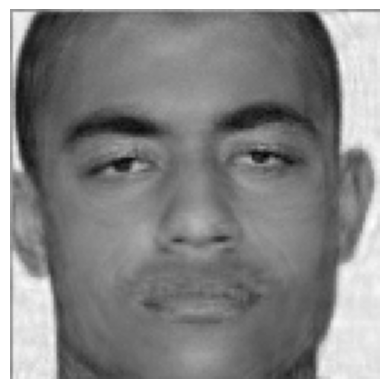

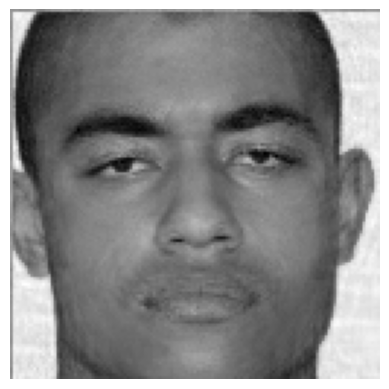

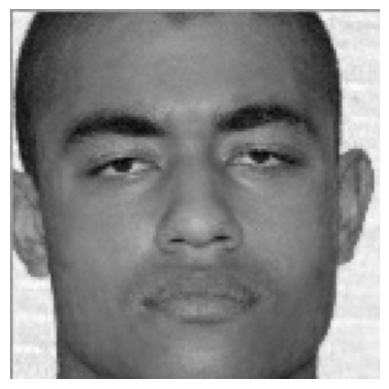

In [27]:
show_face(A[368])
show_face(A5[368])
show_face(A200[368])
show_face(A800[368])
show_face(A1300[368])
show_face(A1700[368])

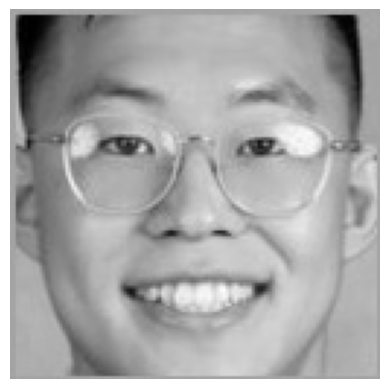

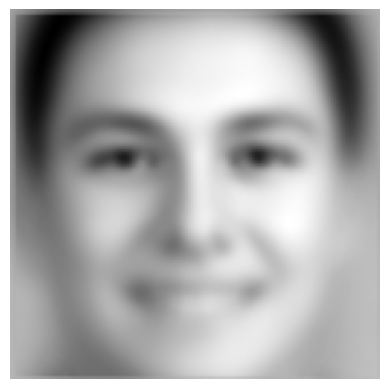

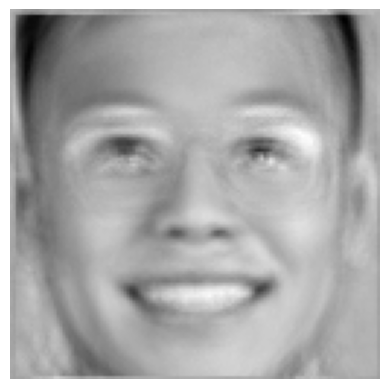

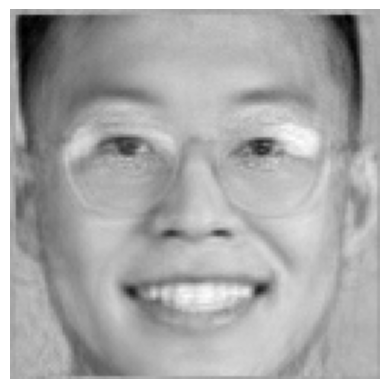

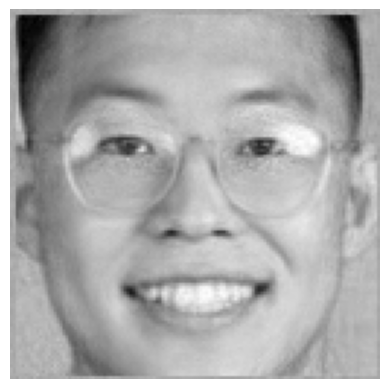

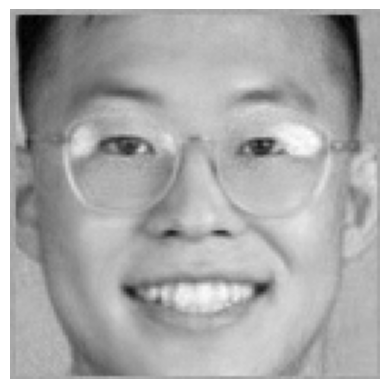

In [28]:
show_face(A[372])
show_face(A5[372])
show_face(A200[372])
show_face(A800[372])
show_face(A1300[372])
show_face(A1700[372])

# Looking at K values we decide 800 kept the most detail without unecessary features.

# Data exploration


People with glasses 